In [ ]:
import pandas as pd
df = pd.read_csv('/content/bank customer churn prediction.zip')
print(df)

      customer_id  credit_score  country  gender  age  tenure    balance  \
0        15634602           619   France  Female   42       2       0.00   
1        15647311           608    Spain  Female   41       1   83807.86   
2        15619304           502   France  Female   42       8  159660.80   
3        15701354           699   France  Female   39       1       0.00   
4        15737888           850    Spain  Female   43       2  125510.82   
...           ...           ...      ...     ...  ...     ...        ...   
9995     15606229           771   France    Male   39       5       0.00   
9996     15569892           516   France    Male   35      10   57369.61   
9997     15584532           709   France  Female   36       7       0.00   
9998     15682355           772  Germany    Male   42       3   75075.31   
9999     15628319           792   France  Female   28       4  130142.79   

      products_number  credit_card  active_member  estimated_salary  churn  
0         

In [ ]:
null_values=df.isnull().sum()
print(null_values)

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [ ]:
X=df.replace({'Female':1,'Male':0,'France':0,'Spain':1,'Germany':2})
print(X)

      customer_id  credit_score  country  gender  age  tenure    balance  \
0        15634602           619        0       1   42       2       0.00   
1        15647311           608        1       1   41       1   83807.86   
2        15619304           502        0       1   42       8  159660.80   
3        15701354           699        0       1   39       1       0.00   
4        15737888           850        1       1   43       2  125510.82   
...           ...           ...      ...     ...  ...     ...        ...   
9995     15606229           771        0       0   39       5       0.00   
9996     15569892           516        0       0   35      10   57369.61   
9997     15584532           709        0       1   36       7       0.00   
9998     15682355           772        2       0   42       3   75075.31   
9999     15628319           792        0       1   28       4  130142.79   

      products_number  credit_card  active_member  estimated_salary  churn  
0         

<ipython-input-5-004efafb714b>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X=df.replace({'Female':1,'Male':0,'France':0,'Spain':1,'Germany':2})


In [ ]:
df=pd.DataFrame({
    'x0':1,
    'x1':X['customer_id'],
    'x2':X['credit_score'],
    'x3':X['country'],
    'x4':X['gender'],
    'x5':X['age'],
    'x6':X['tenure'],
    'x7':X['balance'],
    'x8':X['products_number'],
    'x9':X['credit_card'],
    'x10':X['active_member'],
    'x11':X['estimated_salary'],
    'y':X['churn']

})
print(df)

      x0        x1   x2  x3  x4  x5  x6         x7  x8  x9  x10        x11  y
0      1  15634602  619   0   1  42   2       0.00   1   1    1  101348.88  1
1      1  15647311  608   1   1  41   1   83807.86   1   0    1  112542.58  0
2      1  15619304  502   0   1  42   8  159660.80   3   1    0  113931.57  1
3      1  15701354  699   0   1  39   1       0.00   2   0    0   93826.63  0
4      1  15737888  850   1   1  43   2  125510.82   1   1    1   79084.10  0
...   ..       ...  ...  ..  ..  ..  ..        ...  ..  ..  ...        ... ..
9995   1  15606229  771   0   0  39   5       0.00   2   1    0   96270.64  0
9996   1  15569892  516   0   0  35  10   57369.61   1   1    1  101699.77  0
9997   1  15584532  709   0   1  36   7       0.00   1   0    1   42085.58  1
9998   1  15682355  772   2   0  42   3   75075.31   2   1    0   92888.52  1
9999   1  15628319  792   0   1  28   4  130142.79   1   1    0   38190.78  0

[10000 rows x 13 columns]


In [ ]:
y_counts = df['y'].value_counts()
print(y_counts)

y
0    7963
1    2037
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE
X = df.drop('y', axis=1)
y = df['y']
smote = SMOTE(sampling_strategy=1)
X_resampled, y_resampled = smote.fit_resample(X, y)
y_resampled_counts = y_resampled.value_counts()
print(y_resampled_counts)

y
1    7963
0    7963
Name: count, dtype: int64


In [ ]:
print(X_resampled)
print(y_resampled)

       x0        x1   x2  x3  x4  x5  x6             x7  x8  x9  x10  \
0       1  15634602  619   0   1  42   2       0.000000   1   1    1   
1       1  15647311  608   1   1  41   1   83807.860000   1   0    1   
2       1  15619304  502   0   1  42   8  159660.800000   3   1    0   
3       1  15701354  699   0   1  39   1       0.000000   2   0    0   
4       1  15737888  850   1   1  43   2  125510.820000   1   1    1   
...    ..       ...  ...  ..  ..  ..  ..            ...  ..  ..  ...   
15921   1  15814218  690   2   0  38   4  113785.240946   1   0    0   
15922   1  15758472  684   0   0  45   1       0.000000   1   1    0   
15923   1  15715900  554   1   1  42   5       0.000000   1   0    0   
15924   1  15624132  633   1   0  42   0  126919.189895   1   0    0   
15925   1  15581308  516   0   0  59   1   47847.788104   2   1    0   

                 x11  
0      101348.880000  
1      112542.580000  
2      113931.570000  
3       93826.630000  
4       79084.100000

In [ ]:
from sklearn.model_selection import train_test_split
X_train_resampled, X_test_resampled,y_train_resampled,y_test_resampled = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=30)
print("\nX_train(X_train):")
print(X_train_resampled)
print("\ny_train(y_train):")
print(y_train_resampled)
print("\nX_test(X_test):")
print(X_test_resampled)
print("\ny_test(y_test):")
print(y_test_resampled)


X_train(X_train):
       x0        x1   x2  x3  x4  x5  x6             x7  x8  x9  x10  \
12636   1  15757702  700   0   0  40   7  128957.665684   1   1    0   
12513   1  15761222  678   0   0  55   4       0.000000   1   0    1   
2764    1  15597265  660   0   0  38   7       0.000000   2   0    1   
2230    1  15623277  696   0   1  30   8       0.000000   2   1    1   
15148   1  15813953  627   2   1  42   7  125222.560769   1   1    0   
...    ..       ...  ...  ..  ..  ..  ..            ...  ..  ..  ...   
500     1  15727688  555   1   0  32   4       0.000000   2   1    1   
12077   1  15665976  590   0   1  58   6   75787.105055   3   0    1   
15277   1  15699799  558   0   0  44   7  134207.797322   1   1    0   
4517    1  15787051  750   1   1  39   7  119565.920000   1   1    0   
5925    1  15783477  706   2   1  39   8  112889.910000   1   0    1   

                 x11  
12636   31785.505510  
12513  196742.008687  
2764   146585.530000  
2230   196134.440000  
1

In [ ]:
from sklearn.linear_model import Perceptron
pp=Perceptron()
aa=pp.fit(X_train_resampled,y_train_resampled)
print(aa.intercept_,aa.coef_)

[1.] [[ 1.00000000e+00 -6.56604400e+06 -2.70790000e+05  3.52900000e+03
  -2.25700000e+03  3.35911000e+05 -2.04240000e+04  3.86631547e+08
  -1.05520000e+04 -8.52600000e+03 -1.68830000e+04  2.95653246e+07]]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,aa.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,aa.predict(X_test_resampled)))

0.5
0.5


[[1593    0]
 [1593    0]]


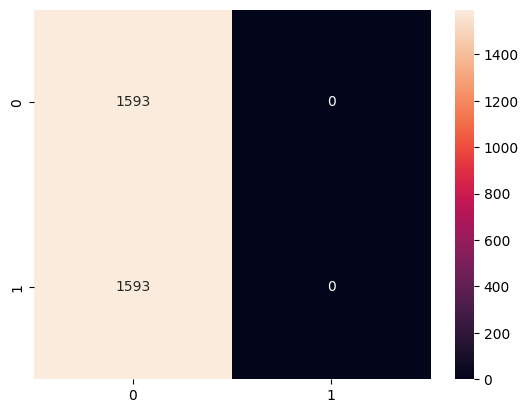

In [ ]:

print(confusion_matrix(y_test_resampled,aa.predict(X_test_resampled)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,aa.predict(X_test_resampled))

sns.heatmap(cm,annot=True,fmt='d')
plt.show()


In [ ]:
print(classification_report(y_test_resampled,aa.predict(X_test_resampled)))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      1593
           1       0.00      0.00      0.00      1593

    accuracy                           0.50      3186
   macro avg       0.25      0.50      0.33      3186
weighted avg       0.25      0.50      0.33      3186



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import SVC
ss=SVC()
mm=ss.fit(X_train_resampled,y_train_resampled)
print(mm.intercept_)

[-0.04910934]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,mm.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,mm.predict(X_test_resampled)))

0.5493720565149136
0.5426867545511613


[[1053  540]
 [ 917  676]]


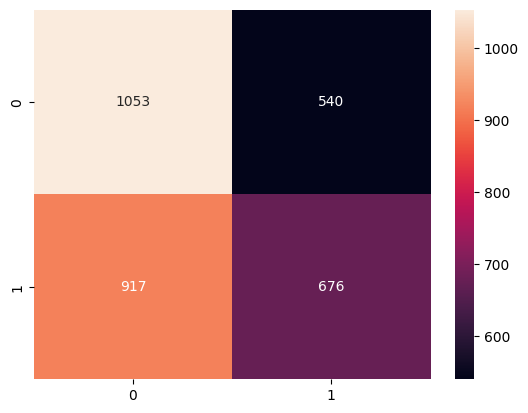

In [ ]:
print(confusion_matrix(y_test_resampled,mm.predict(X_test_resampled)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,mm.predict(X_test_resampled))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test_resampled,mm.predict(X_test_resampled)))

              precision    recall  f1-score   support

           0       0.53      0.66      0.59      1593
           1       0.56      0.42      0.48      1593

    accuracy                           0.54      3186
   macro avg       0.55      0.54      0.54      3186
weighted avg       0.55      0.54      0.54      3186



In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
kk=lr.fit(X_train_resampled,y_train_resampled)
print(kk.intercept_,kk.coef_)

[1.51764314e-07] [[ 1.51764313e-07 -2.20538892e-07 -5.04190507e-04  4.55490158e-04
  -5.31310376e-04  8.31692181e-02 -4.85564696e-03  4.90601045e-06
  -2.42132303e-03 -2.09329689e-03 -4.23517814e-03  4.18789272e-07]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,kk.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,kk.predict(X_test_resampled)))

0.7010204081632653
0.7027620841180163


[[1112  481]
 [ 466 1127]]


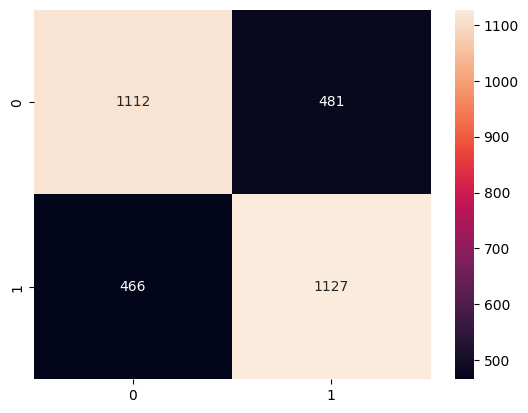

In [ ]:
print(confusion_matrix(y_test_resampled,kk.predict(X_test_resampled)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,kk.predict(X_test_resampled))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test_resampled,kk.predict(X_test_resampled)))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70      1593
           1       0.70      0.71      0.70      1593

    accuracy                           0.70      3186
   macro avg       0.70      0.70      0.70      3186
weighted avg       0.70      0.70      0.70      3186



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kk=KNeighborsClassifier()
nn=kk.fit(X_train_resampled,y_train_resampled)
print(nn.score(X_train_resampled,y_train_resampled))
print(nn.score(X_test_resampled,y_test_resampled))



0.8143642072213501
0.6952291274325173


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,nn.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,nn.predict(X_test_resampled)))

0.8143642072213501
0.6952291274325173


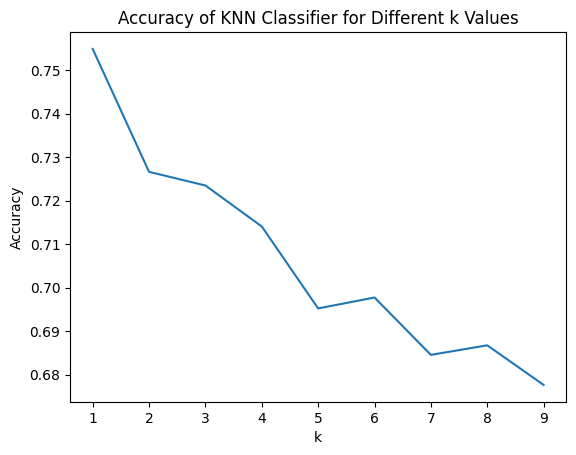

In [ ]:
import matplotlib.pyplot as plt
k_values = range(1,10)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_resampled, y_train_resampled)
    accuracy = knn.score(X_test_resampled, y_test_resampled)
    accuracies.append(accuracy)
plt.plot(k_values, accuracies)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy of KNN Classifier for Different k Values')
plt.show()

[[ 901  692]
 [ 279 1314]]


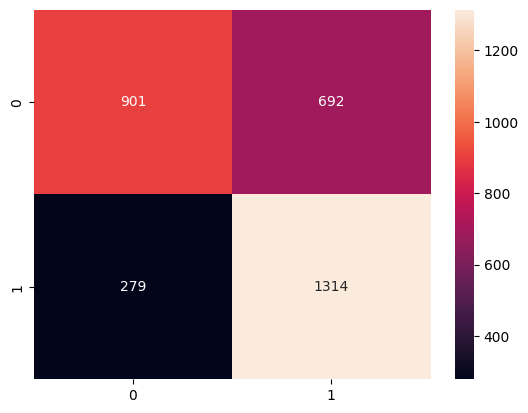

In [ ]:
print(confusion_matrix(y_test_resampled,nn.predict(X_test_resampled)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,nn.predict(X_test_resampled))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test_resampled,nn.predict(X_test_resampled)))

              precision    recall  f1-score   support

           0       0.76      0.57      0.65      1593
           1       0.66      0.82      0.73      1593

    accuracy                           0.70      3186
   macro avg       0.71      0.70      0.69      3186
weighted avg       0.71      0.70      0.69      3186



In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=5)
s=pca.fit_transform(X_resampled)

s=pd.DataFrame(data=s,columns=['x0','x1','x2','x3','x4'])
print(s)



                  x0            x1            x2          x3         x4
0      -51303.476917 -85119.098683   2964.428051  -28.952193   1.680909
1      -43737.078286   -398.799186  11670.485855  -40.824745   0.033249
2      -76293.927324  73622.651538  10739.877217 -147.896886   0.266176
3       15352.737622 -81292.358431  -4432.794464   50.865408  -1.264743
4       44267.338183  45710.073691 -22854.794121  199.625079   1.970591
...              ...           ...           ...         ...        ...
15921  120815.196826  41523.292233  74465.873456   42.721105  -3.295932
15922   72323.238034 -77481.461225   7271.520386   36.232446   4.645775
15923   29923.203405 -80829.579644 -18520.252695  -94.549216   1.477414
15924  -69587.341750  42039.138089  38295.299969  -15.633172   0.778445
15925 -107715.747288 -38018.653278  88699.990401 -130.107639  18.217220

[15926 rows x 5 columns]


In [ ]:
s_train,s_test,y_train,y_test=train_test_split(s,y_resampled,test_size=0.2,random_state=42)
print("\nxTrain:")
print(s_train)
print("\nxTest:")
print(s_test)
print("\nyTrain:")
print(y_train)
print("\nyTest:")
print(y_test)



xTrain:
                  x0             x1            x2          x3         x4
13555 -116696.118423   54831.241034  71047.550598 -108.889201   6.505578
1665    80900.107465   54139.551325  41510.934363  100.498879   0.740182
14878   92050.635937   68682.143666 -47589.659809  -82.362803  -1.650641
7471    28206.506271   39751.016196  17637.784374    8.887614  13.695068
2582    10164.954111   33301.582683  37182.182493    7.552151   4.768734
...              ...            ...           ...         ...        ...
13418  -69275.609476  -85706.752809  19779.183953  -98.458362  -0.420889
5390  -111909.273746  -89076.798970  -6270.956633   86.748896  -2.069541
860    109925.096084  115060.437797  -6246.923140   16.275002   1.079257
15795   58401.834065   78701.908896  53788.832432   73.508348  -0.481195
7270    11440.955506   65381.412455 -49073.656974   45.514275   9.627133

[12740 rows x 5 columns]

xTest:
                  x0            x1            x2          x3         x4
6126   10

In [ ]:
from sklearn.linear_model import Perceptron
pp=Perceptron()
aa=pp.fit(s_train,y_train)
print(aa.intercept_,aa.coef_)

[-564.] [[ -88859.97255962    7377.9328866    13530.24892983 -255249.37098627
   312543.70853367]]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,aa.predict(s_train)))
print(accuracy_score(y_test,aa.predict(s_test)))

0.5029827315541602
0.5188323917137476


[[834 799]
 [734 819]]


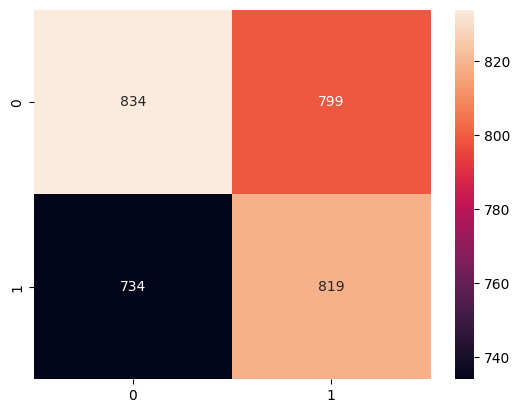

In [ ]:
print(confusion_matrix(y_test,aa.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,aa.predict(s_test))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()


In [ ]:
print(classification_report(y_test,aa.predict(s_test)))

              precision    recall  f1-score   support

           0       0.53      0.51      0.52      1633
           1       0.51      0.53      0.52      1553

    accuracy                           0.52      3186
   macro avg       0.52      0.52      0.52      3186
weighted avg       0.52      0.52      0.52      3186



In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
kk=lr.fit(s_train,y_train)
print(kk.intercept_,kk.coef_)

[0.03021192] [[-1.05134846e-07  5.63608590e-06  3.66681867e-07 -9.13834438e-04
   8.54934494e-02]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,kk.predict(s_train)))
print(accuracy_score(y_test,kk.predict(s_test)))

0.7014128728414443
0.7008788449466415


[[1156  477]
 [ 476 1077]]


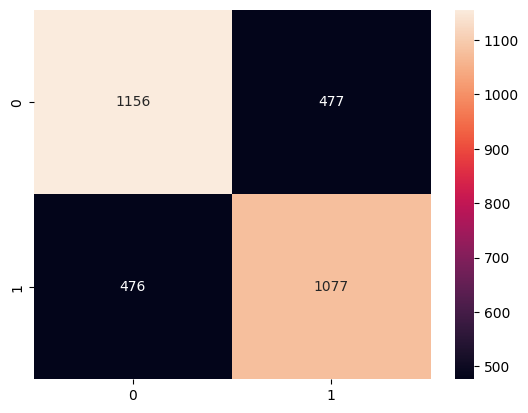

In [ ]:
print(confusion_matrix(y_test,kk.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,kk.predict(s_test))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,kk.predict(s_test)))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      1633
           1       0.69      0.69      0.69      1553

    accuracy                           0.70      3186
   macro avg       0.70      0.70      0.70      3186
weighted avg       0.70      0.70      0.70      3186



In [ ]:
from sklearn.svm import SVC
ss=SVC()
mm=ss.fit(s_train,y_train)
print(mm.intercept_)

[-0.0801672]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,mm.predict(s_train)))
print(accuracy_score(y_test,mm.predict(s_test)))

0.5715070643642072
0.5747018204645323


[[ 661  972]
 [ 383 1170]]


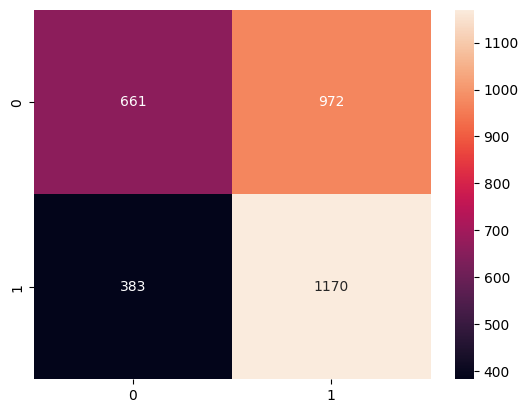

In [ ]:
print(confusion_matrix(y_test,mm.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,mm.predict(s_test))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,mm.predict(s_test)))

              precision    recall  f1-score   support

           0       0.63      0.40      0.49      1633
           1       0.55      0.75      0.63      1553

    accuracy                           0.57      3186
   macro avg       0.59      0.58      0.56      3186
weighted avg       0.59      0.57      0.56      3186



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kk=KNeighborsClassifier()
nn=kk.fit(s_train,y_train)
print(nn.score(s_train,y_train))
print(nn.score(s_test,y_test))

0.8111459968602825
0.7059008160703076


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,nn.predict(s_train)))
print(accuracy_score(y_test,nn.predict(s_test)))

0.8111459968602825
0.7059008160703076


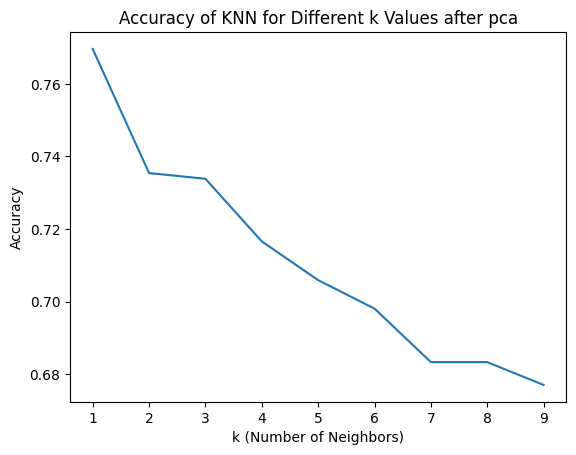

In [ ]:
import matplotlib.pyplot as plt
k_values = range(1,10)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(s_train, y_train)
    accuracy = knn.score(s_test, y_test)
    accuracies.append(accuracy)
plt.plot(k_values, accuracies)
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("Accuracy of KNN for Different k Values after pca")
plt.show()

[[ 981  652]
 [ 285 1268]]


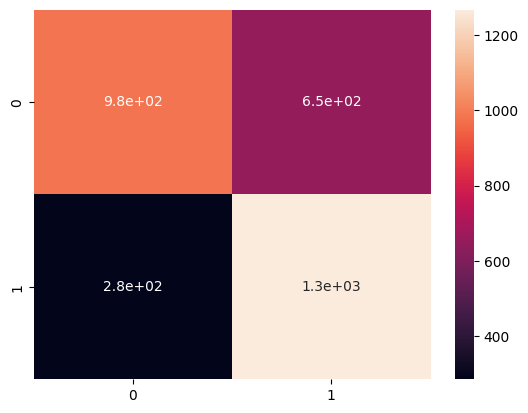

In [ ]:
print(confusion_matrix(y_test,nn.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,nn.predict(s_test))
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
print(classification_report(y_test,nn.predict(s_test)))

              precision    recall  f1-score   support

           0       0.77      0.60      0.68      1633
           1       0.66      0.82      0.73      1553

    accuracy                           0.71      3186
   macro avg       0.72      0.71      0.70      3186
weighted avg       0.72      0.71      0.70      3186



In [ ]:
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
n_iterations=10
accuracy_scores_lr=[]
for _ in range(n_iterations):
    X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
    X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
    lr = LogisticRegression()
    lr.fit(X_train_boot, y_train_boot)
    accuracy_scores_lr.append(accuracy_score(y_test_resampled, lr.predict(X_test_resampled)))

accuracy_scores_lr

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[0.6964846202134338,
 0.5668549905838042,
 0.5684243565599498,
 0.6980539861895794,
 0.7015065913370998,
 0.6980539861895794,
 0.5775266792215945,
 0.6820464532328939,
 0.6880100439422473,
 0.694601381042059]

In [ ]:
n_iterations=10
accuracy_scores_svm=[]
for _ in range(n_iterations):
    X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
    X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
    svm = SVC()
    svm.fit(X_train_boot, y_train_boot)
    accuracy_scores_svm.append(accuracy_score(y_test_resampled, svm.predict(X_test_resampled)))
    print(accuracy_scores_svm)

[0.5]
[0.5, 0.5]
[0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]


In [ ]:
n_iterations=10
accuracy_scores_knn=[]
for _ in range(n_iterations):
  X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
  X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
  knn = KNeighborsClassifier()
  knn.fit(X_train_boot, y_train_boot)
  accuracy_scores_knn.append(accuracy_score(y_test_resampled, knn.predict(X_test_resampled)))
  print(accuracy_scores_knn)

[0.7341494036409291]
[0.7341494036409291, 0.7344632768361582]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199, 0.7391713747645952]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199, 0.7391713747645952, 0.7372881355932204]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199, 0.7391713747645952, 0.7372881355932204, 0.7410546139359698]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199, 0.7391713747645952, 0.7372881355932204, 0.7410546139359698, 0.746390458254865]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199, 0.7391713747645952, 0.7372881355932204, 0.7410546139359698, 0.746390458254865, 0.7548650345260515]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199, 0.7391713747645952, 0.7372881355932204, 0.7410546139359698, 0.746390458254865, 0.7548650345260515, 0.7319522912743252]
[0.7341494036409291, 0.7344632768361582, 0.741368487131199, 0.7391713747645952, 0.7372881355932204, 0

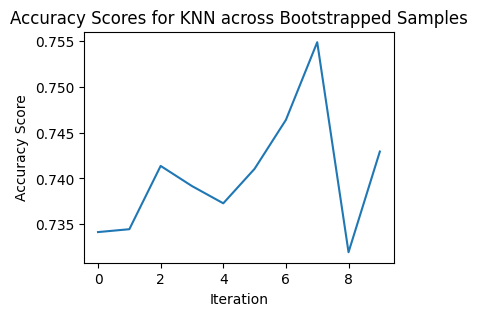

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 3))
plt.plot(accuracy_scores_knn)
plt.xlabel("Iteration")
plt.ylabel("Accuracy Score")
plt.title("Accuracy Scores for KNN across Bootstrapped Samples")
plt.show()

In [ ]:
n_iterations=10
accuracy_scores_perceptron=[]
for _ in range(n_iterations):
  X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
  X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
  perceptron = Perceptron()
  perceptron.fit(X_train_boot, y_train_boot)
  accuracy_scores_perceptron.append(accuracy_score(y_test_resampled, perceptron.predict(X_test_resampled)))
  print(accuracy_scores_perceptron)

[0.5]
[0.5, 0.5]
[0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5646578782172003]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5646578782172003, 0.5]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5646578782172003, 0.5, 0.5006277463904583]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5646578782172003, 0.5, 0.5006277463904583, 0.5]


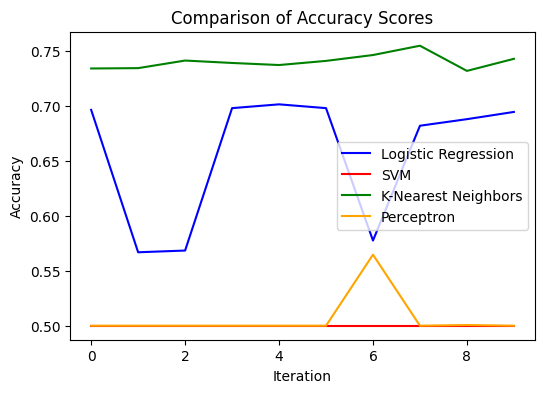

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
plt.plot(accuracy_scores_lr, label='Logistic Regression',color='blue')
plt.plot(accuracy_scores_svm, label='SVM',color='red')
plt.plot(accuracy_scores_knn, label='K-Nearest Neighbors',color='green')
plt.plot(accuracy_scores_perceptron, label='Perceptron',color='orange')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracy Scores')
plt.legend()
plt.show()
